In [1]:
# ── Cellule 1 : Imports & Configuration ──────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from collections import Counter
import re
import nltk
from pathlib import Path

# Téléchargement des ressources NLTK
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.corpus import stopwords

# ── Style global ─────────────────────────────────────────────────────────────
plt.style.use("dark_background")
PALETTE = {
    "RUNWAY_CLOSURE":       "#ef4444",
    "NAVIGATION_AID":       "#3b82f6",
    "AIRSPACE_RESTRICTION": "#f59e0b",
    "LIGHTING":             "#8b5cf6",
    "OBSTACLE":             "#10b981",
    "AERODROME_PROCEDURE":  "#ec4899",
}
COLOR_LIST = list(PALETTE.values())

# Stopwords aviation-aware (on retire les mots trop génériques ET les codes ICAO)
AVIATION_STOPWORDS = set(stopwords.words("english")) | {
    "rwy", "twy", "apt", "acft", "notam", "notamn", "avbl",
    "effective", "clsd", "due", "within", "will", "not", "auth",
    "ots", "opr", "ops", "flt", "info", "ppr", "req",
}

DATA_PATH = Path("../data/raw/notams.csv")
print("✅ Configuration OK")

✅ Configuration OK


In [2]:
# ── Cellule 2 : Chargement & Inspection Initiale ─────────────────────────────
df = pd.read_csv(DATA_PATH)

print("=" * 60)
print(f"  NOTAM DATASET — INSPECTION INITIALE")
print("=" * 60)
print(f"\n📐 Shape            : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"🗂️  Colonnes         : {list(df.columns)}")
print(f"🏷️  Catégories       : {df['category'].nunique()} classes")
print(f"✈️  Aéroports ICAO   : {df['icao_location'].nunique()} codes")
print(f"🔑 Q-codes uniques  : {df['q_code'].nunique()}")
print(f"\n── Types de données ─────────────────────────────────────")
print(df.dtypes)
print(f"\n── Valeurs manquantes ───────────────────────────────────")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "  ✅ Aucune valeur manquante")
print(f"\n── Aperçu (3 premiers) ──────────────────────────────────")
pd.set_option("display.max_colwidth", 80)
df.head(3)

  NOTAM DATASET — INSPECTION INITIALE

📐 Shape            : 2,400 lignes × 10 colonnes
🗂️  Colonnes         : ['notam_id', 'icao_location', 'q_code', 'category', 'effective_start', 'effective_end', 'body_text', 'full_text', 'char_count', 'word_count']
🏷️  Catégories       : 6 classes
✈️  Aéroports ICAO   : 10 codes
🔑 Q-codes uniques  : 19

── Types de données ─────────────────────────────────────
notam_id             str
icao_location        str
q_code               str
category             str
effective_start    int64
effective_end      int64
body_text            str
full_text            str
char_count         int64
word_count         int64
dtype: object

── Valeurs manquantes ───────────────────────────────────
  ✅ Aucune valeur manquante

── Aperçu (3 premiers) ──────────────────────────────────


,notam_id,icao_location,q_code,category,effective_start,effective_end,body_text,full_text,char_count,word_count
0,A1539/24,OMDB,QNDXX,NAVIGATION_AID,2603091940,2603220740,ILS RWY 28R NOT AVAILABLE,A1539/24 NOTAMN\nQ) OMZX/QNDXX/IV/NBO/A/000/999/5000N00000E999\nA) OMDB B) 2...,25,5
1,A2470/24,KLAX,QLTBA,LIGHTING,2603061340,2603240440,VASI RWY 23 UNSERVICEABLE,A2470/24 NOTAMN\nQ) KLZX/QLTBA/IV/NBO/A/000/999/5000N00000E999\nA) KLAX B) 2...,25,4
2,A2657/24,YSSY,QOBXX,OBSTACLE,2603081040,2603302140,CRANE 3002FT ERECTED 3.4NM NW OF LFPG ARP,A2657/24 NOTAMN\nQ) YSZX/QOBXX/IV/NBO/A/000/999/5000N00000E999\nA) YSSY B) 2...,41,8


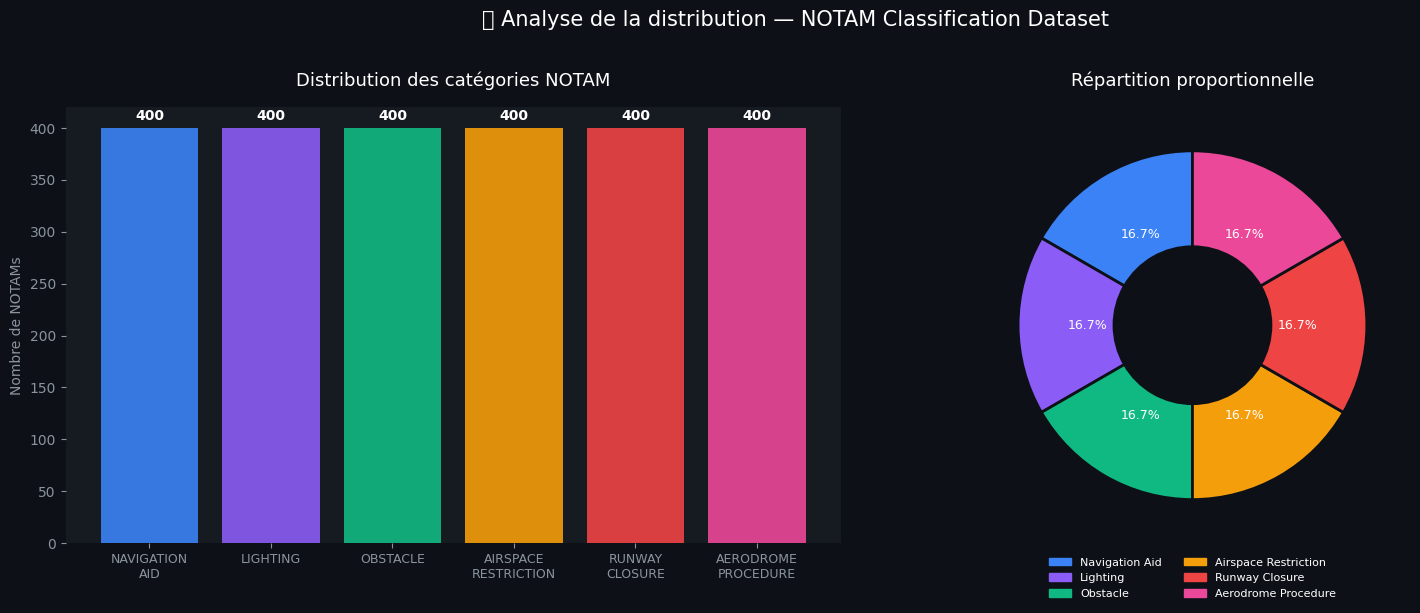


📊 Ratio max/min : 1.00x → dataset parfaitement équilibré


In [3]:
# ── Cellule 3 : Distribution des Classes ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0d1117")

# ── Bar chart ────────────────────────────────────────────────────────────────
counts = df["category"].value_counts()
colors = [PALETTE[c] for c in counts.index]
bars = axes[0].bar(range(len(counts)), counts.values, color=colors, edgecolor="none", alpha=0.9)
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels([c.replace("_", "\n") for c in counts.index], fontsize=9)
axes[0].set_facecolor("#161b22")
axes[0].set_title("Distribution des catégories NOTAM", fontsize=13, color="white", pad=15)
axes[0].set_ylabel("Nombre de NOTAMs", color="#8b949e")
axes[0].tick_params(colors="#8b949e")
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha="center", va="bottom", color="white", fontsize=10, fontweight="bold")
axes[0].spines[:].set_visible(False)

# ── Donut chart ──────────────────────────────────────────────────────────────
wedges, texts, autotexts = axes[1].pie(
    counts.values,
    labels=None,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="#0d1117", linewidth=2),
)
for at in autotexts:
    at.set_color("white"); at.set_fontsize(9)
axes[1].set_facecolor("#161b22")
axes[1].set_title("Répartition proportionnelle", fontsize=13, color="white", pad=15)
legend_patches = [mpatches.Patch(color=PALETTE[c], label=c.replace("_", " ").title()) for c in counts.index]
axes[1].legend(handles=legend_patches, loc="lower center", bbox_to_anchor=(0.5, -0.15),
               ncol=2, fontsize=8, framealpha=0, labelcolor="white")

plt.suptitle("🛫 Analyse de la distribution — NOTAM Classification Dataset",
             fontsize=15, color="white", y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/fig_01_class_distribution.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print(f"\n📊 Ratio max/min : {counts.max()/counts.min():.2f}x → dataset parfaitement équilibré")

── Statistiques de longueur par catégorie ───────────────
                     text_length                  word_count                
                            mean median   std max       mean median  std max
category                                                                    
AERODROME_PROCEDURE         27.5   26.0   7.5  42        4.8    5.0  1.5   7
AIRSPACE_RESTRICTION        41.7   41.0   7.0  57        6.9    7.0  1.9  11
LIGHTING                    19.8   19.0   4.4  28        4.5    4.0  0.7   6
NAVIGATION_AID              24.1   25.0   7.2  36        4.9    5.0  1.5   7
OBSTACLE                    42.8   43.0   4.4  51        6.7    7.0  1.4   9
RUNWAY_CLOSURE              30.0   29.5  12.2  54        5.9    5.0  1.8   9


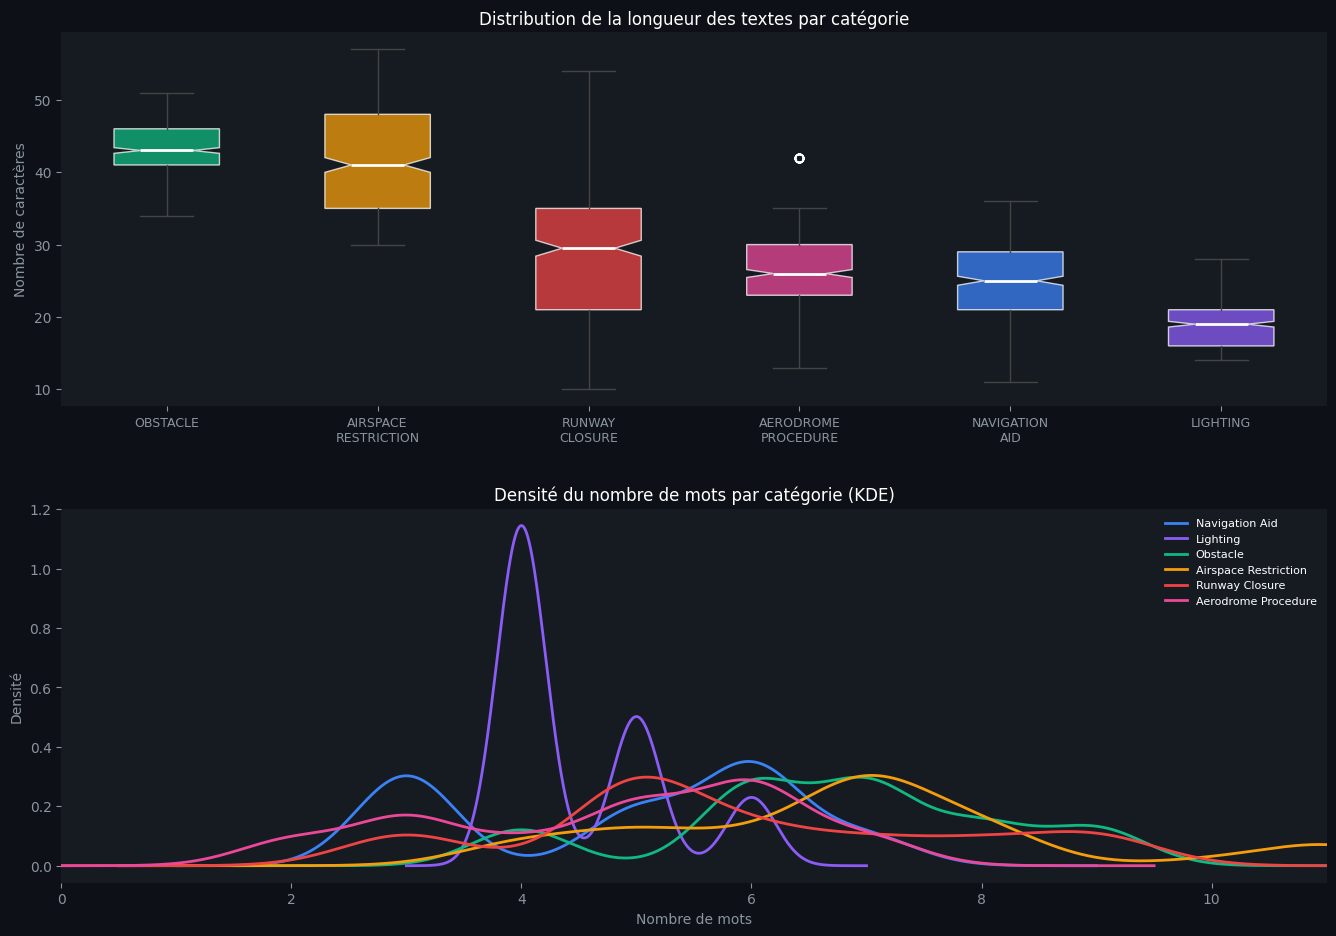

In [4]:
# ── Cellule 4 : Analyse des Longueurs de Texte ───────────────────────────────
df["text_length"]  = df["body_text"].str.len()
df["word_count"]   = df["body_text"].str.split().str.len()
df["token_count"]  = df["body_text"].str.split().str.len()

print("── Statistiques de longueur par catégorie ───────────────")
stats = df.groupby("category")[["text_length", "word_count"]].agg(["mean", "median", "std", "max"])
print(stats.round(1).to_string())

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor("#0d1117")

# ── Boxplot longueur de texte ─────────────────────────────────────────────────
order = df.groupby("category")["text_length"].median().sort_values(ascending=False).index
cat_data = [df[df["category"] == c]["text_length"].values for c in order]
bp = axes[0].boxplot(cat_data, patch_artist=True, notch=True,
                     medianprops=dict(color="white", linewidth=2))
for patch, cat in zip(bp["boxes"], order):
    patch.set_facecolor(PALETTE[cat]); patch.set_alpha(0.75)
for element in ["whiskers", "caps", "fliers"]:
    for item in bp[element]:
        item.set_color("#444")
axes[0].set_xticklabels([c.replace("_", "\n") for c in order], fontsize=9, color="#8b949e")
axes[0].set_facecolor("#161b22"); axes[0].set_title("Distribution de la longueur des textes par catégorie",
    fontsize=12, color="white"); axes[0].set_ylabel("Nombre de caractères", color="#8b949e")
axes[0].spines[:].set_visible(False); axes[0].tick_params(colors="#8b949e")

# ── KDE plot ─────────────────────────────────────────────────────────────────
axes[1].set_facecolor("#161b22")
for cat in df["category"].unique():
    subset = df[df["category"] == cat]["word_count"]
    subset.plot.kde(ax=axes[1], color=PALETTE[cat], linewidth=2,
                    label=cat.replace("_", " ").title())
axes[1].set_title("Densité du nombre de mots par catégorie (KDE)", fontsize=12, color="white")
axes[1].set_xlabel("Nombre de mots", color="#8b949e")
axes[1].set_ylabel("Densité", color="#8b949e")
axes[1].legend(fontsize=8, framealpha=0, labelcolor="white")
axes[1].spines[:].set_visible(False); axes[1].tick_params(colors="#8b949e")
axes[1].set_xlim(0, df["word_count"].quantile(0.99))

plt.tight_layout(pad=3)
plt.savefig("../data/processed/fig_02_text_length.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()

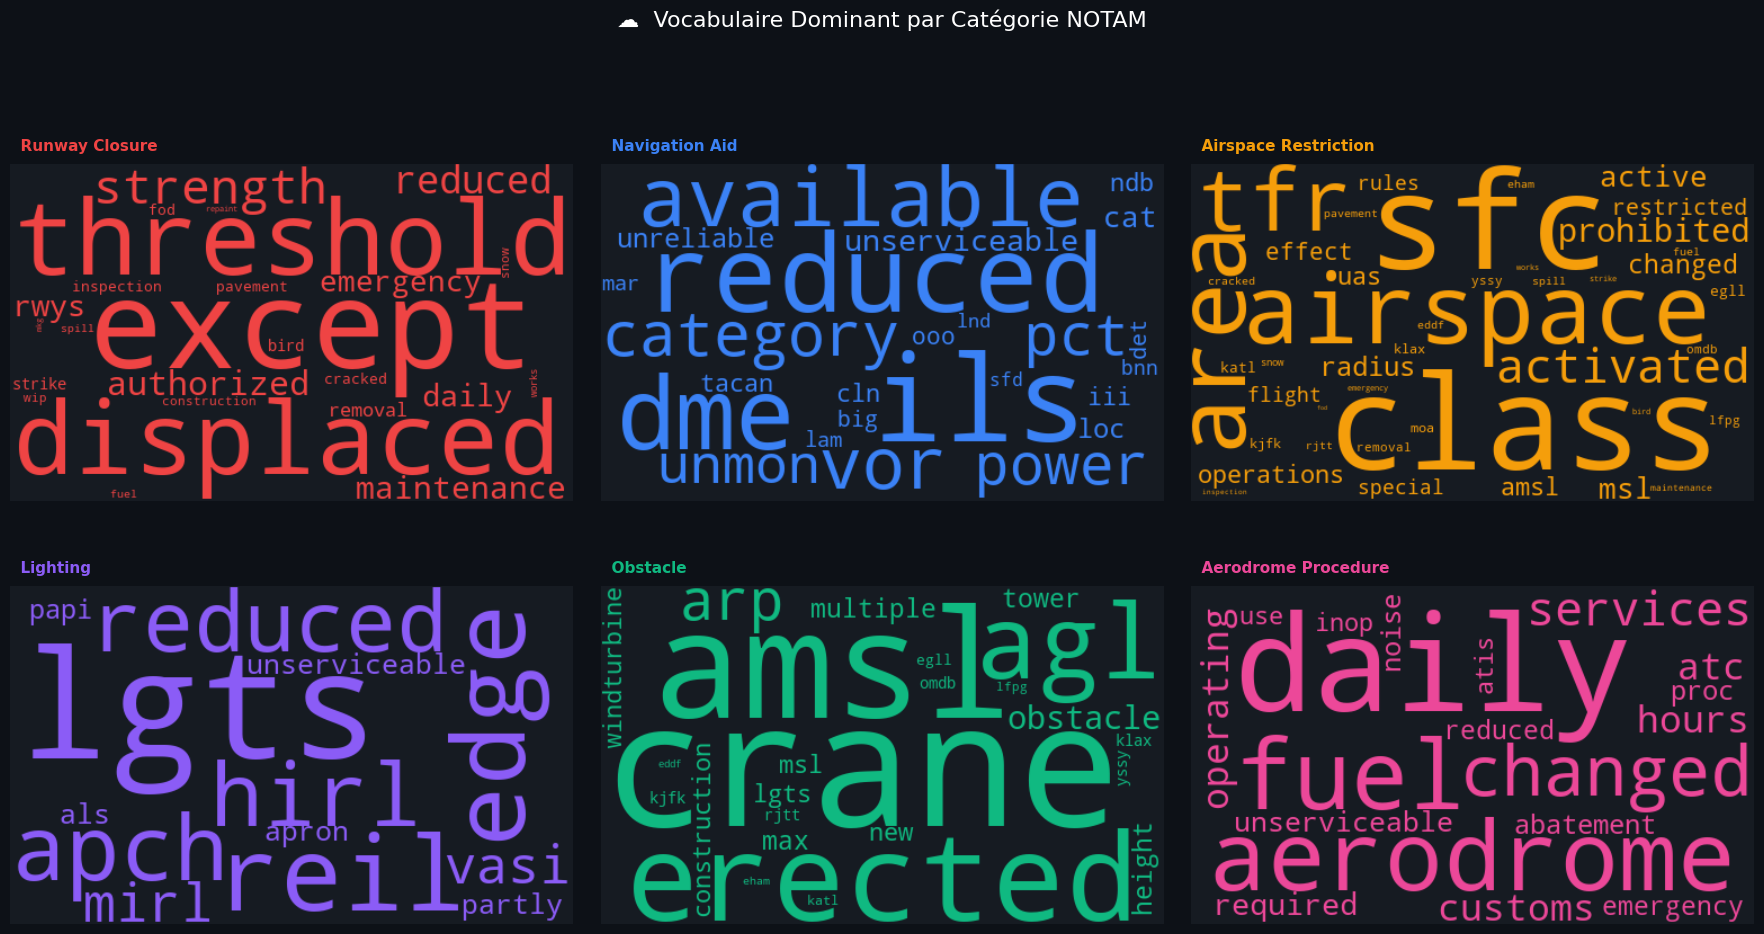

In [5]:
# ── Cellule 5 : WordClouds par Catégorie ─────────────────────────────────────
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"\b\d+\w*\b", "", text)       # Retire les nombres/codes
    text = re.sub(r"[^a-z\s]", " ", text)         # Garde seulement les lettres
    tokens = [w for w in text.split() if w not in AVIATION_STOPWORDS and len(w) > 2]
    return " ".join(tokens)

df["clean_text"] = df["body_text"].apply(clean_text)

categories = list(PALETTE.keys())
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor("#0d1117")

for ax, cat in zip(axes.flatten(), categories):
    corpus = " ".join(df[df["category"] == cat]["clean_text"].values)
    if not corpus.strip():
        ax.axis("off"); continue

    wc = WordCloud(
        width=500, height=300,
        background_color="#161b22",
        colormap=None,
        color_func=lambda *a, **kw: PALETTE[cat],
        max_words=60,
        prefer_horizontal=0.85,
        collocations=False,
    ).generate(corpus)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"  {cat.replace('_', ' ').title()}", fontsize=11,
                 color=PALETTE[cat], pad=10, loc="left", fontweight="bold")
    ax.axis("off")

plt.suptitle("☁️  Vocabulaire Dominant par Catégorie NOTAM", fontsize=16,
             color="white", y=1.01)
plt.tight_layout(pad=2)
plt.savefig("../data/processed/fig_03_wordclouds.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()

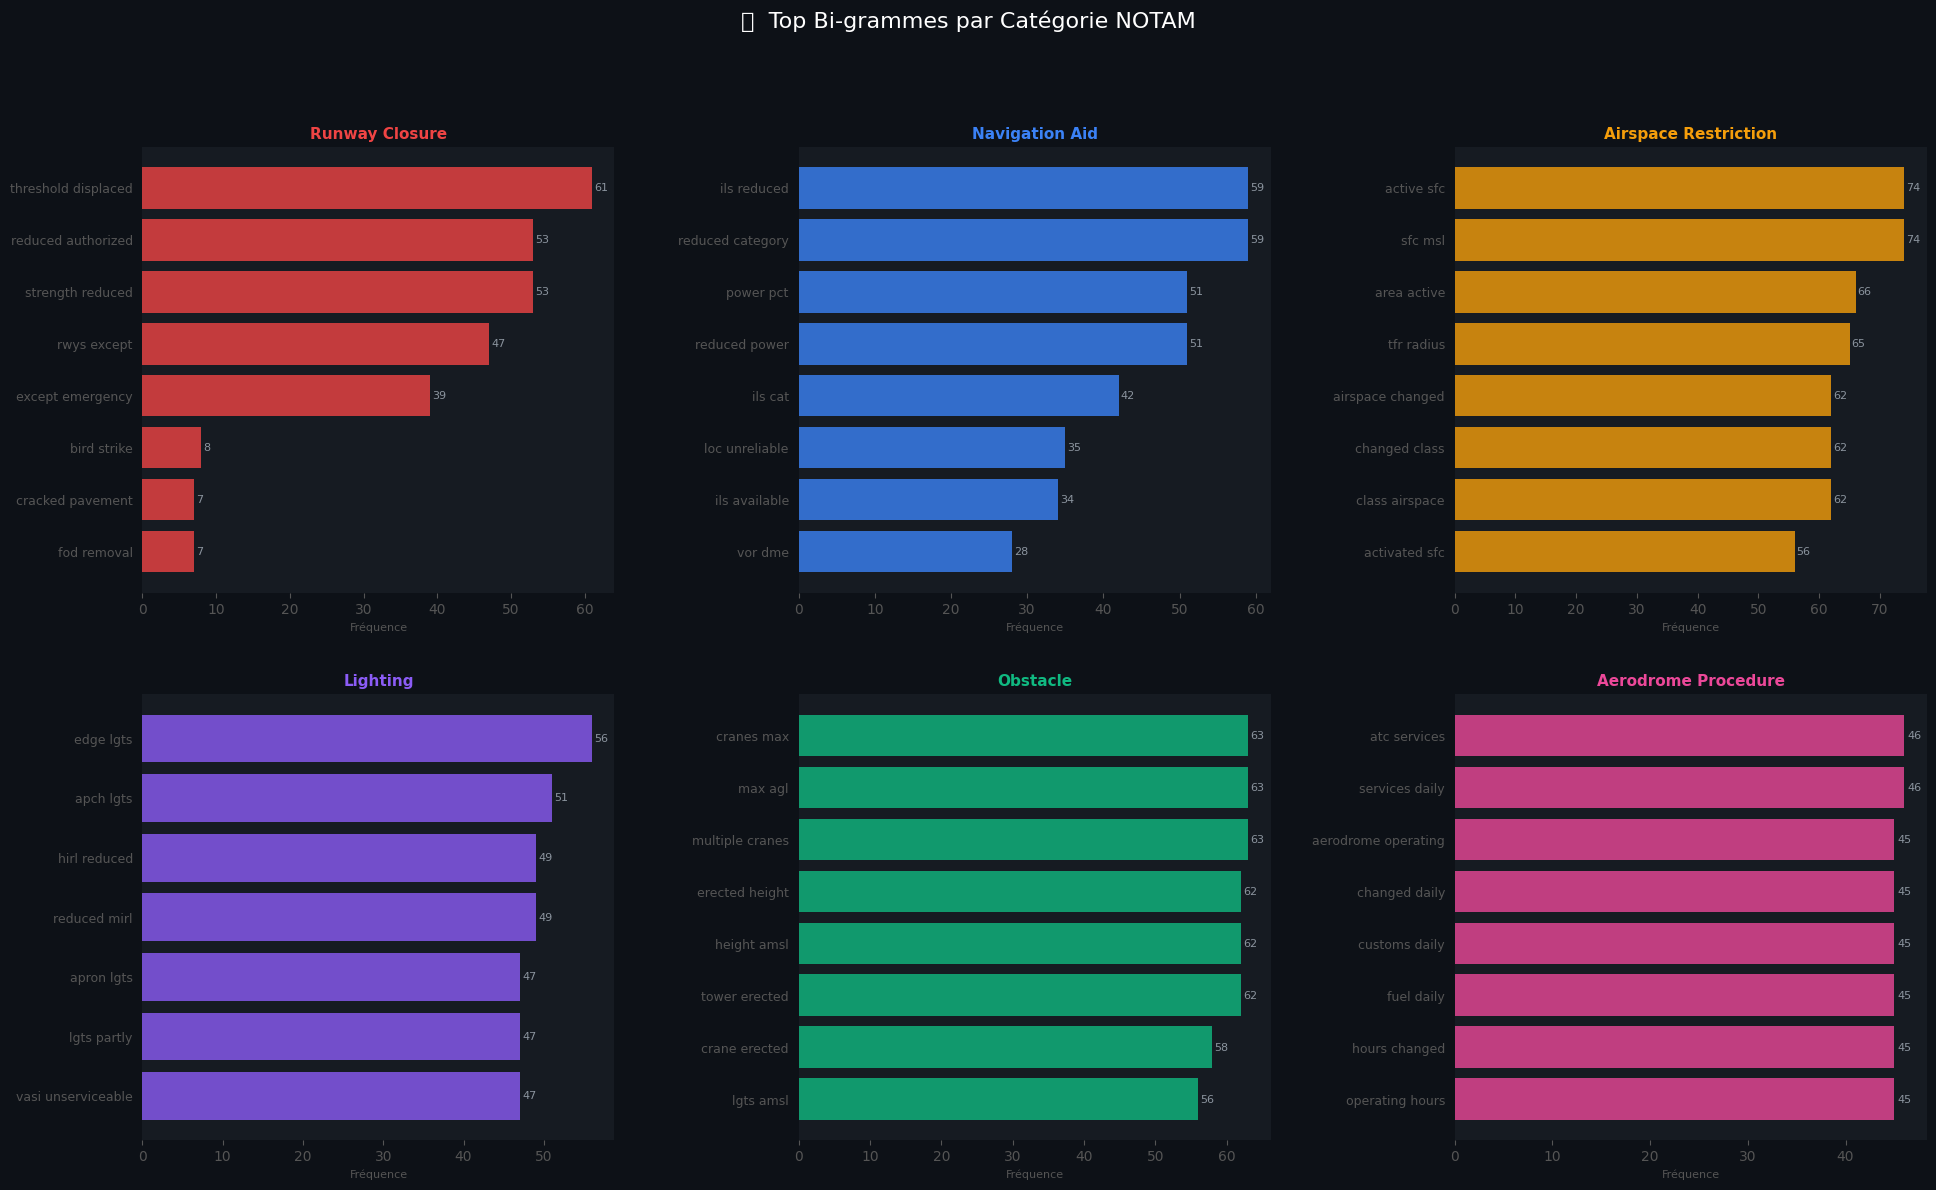

In [6]:
# ── Cellule 6 : Top N-Grams par Catégorie ────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=2, top_k=10):
    vec = CountVectorizer(ngram_range=(n, n), max_features=200,
                          stop_words=list(AVIATION_STOPWORDS)).fit(corpus)
    bag = vec.transform(corpus)
    freqs = zip(vec.get_feature_names_out(), bag.sum(axis=0).tolist()[0])
    return sorted(freqs, key=lambda x: x[1], reverse=True)[:top_k]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.patch.set_facecolor("#0d1117")

for ax, cat in zip(axes.flatten(), categories):
    corpus = df[df["category"] == cat]["clean_text"].tolist()
    top = get_top_ngrams(corpus, n=2, top_k=8)
    if not top:
        ax.axis("off"); continue
    labels, values = zip(*top)
    
    color = PALETTE[cat]
    bars = ax.barh(range(len(labels)), values, color=color, alpha=0.8, edgecolor="none")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9, color="white")
    ax.invert_yaxis()
    ax.set_facecolor("#161b22")
    ax.set_title(cat.replace("_", " ").title(), color=color, fontsize=11, fontweight="bold")
    ax.spines[:].set_visible(False)
    ax.tick_params(colors="#555", left=False)
    ax.set_xlabel("Fréquence", color="#555", fontsize=8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(int(val)), va="center", color="#8b949e", fontsize=8)

plt.suptitle("🔤  Top Bi-grammes par Catégorie NOTAM", fontsize=16, color="white", y=1.01)
plt.tight_layout(pad=3)
plt.savefig("../data/processed/fig_04_ngrams.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()

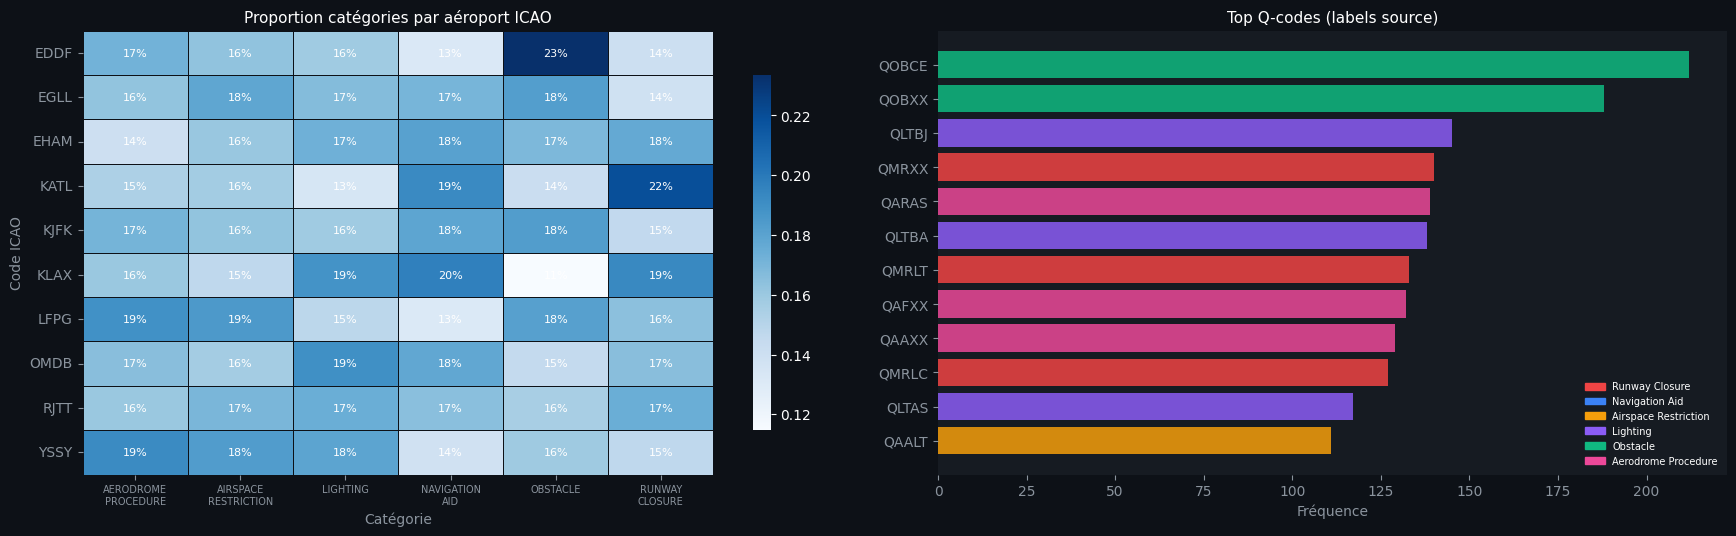

In [7]:
# ── Cellule 7 : Distribution par Aéroport & Q-Code ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor("#0d1117")

# ── Heatmap ICAO × Catégorie ─────────────────────────────────────────────────
pivot = df.groupby(["icao_location", "category"]).size().unstack(fill_value=0)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

sns.heatmap(
    pivot_norm, ax=axes[0],
    cmap="Blues", linewidths=0.5, linecolor="#0d1117",
    annot=True, fmt=".0%", annot_kws={"size": 8, "color": "white"},
    cbar_kws={"shrink": 0.8},
)
axes[0].set_facecolor("#161b22")
axes[0].set_title("Proportion catégories par aéroport ICAO", color="white", fontsize=11)
axes[0].tick_params(colors="#8b949e", rotation=0)
axes[0].set_xlabel("Catégorie", color="#8b949e")
axes[0].set_ylabel("Code ICAO", color="#8b949e")
axes[0].set_xticklabels([l.get_text().replace("_", "\n") for l in axes[0].get_xticklabels()], fontsize=7)

# ── Top Q-codes ───────────────────────────────────────────────────────────────
q_counts = df.groupby(["q_code", "category"]).size().reset_index(name="count")
q_top = q_counts.nlargest(12, "count")
colors_q = [PALETTE[c] for c in q_top["category"]]
axes[1].barh(q_top["q_code"], q_top["count"], color=colors_q, edgecolor="none", alpha=0.85)
axes[1].invert_yaxis()
axes[1].set_facecolor("#161b22")
axes[1].set_title("Top Q-codes (labels source)", color="white", fontsize=11)
axes[1].spines[:].set_visible(False)
axes[1].tick_params(colors="#8b949e")
axes[1].set_xlabel("Fréquence", color="#8b949e")
legend_patches = [mpatches.Patch(color=v, label=k.replace("_"," ").title()) for k,v in PALETTE.items()]
axes[1].legend(handles=legend_patches, fontsize=7, framealpha=0, labelcolor="white", loc="lower right")

plt.tight_layout(pad=3)
plt.savefig("../data/processed/fig_05_airport_qcode.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()

🔄 Calcul TF-IDF + SVD (2D projection)...
  Matrice TF-IDF : 2,400 docs × 301 features
  Variance expliquée (2D) : 6.5%


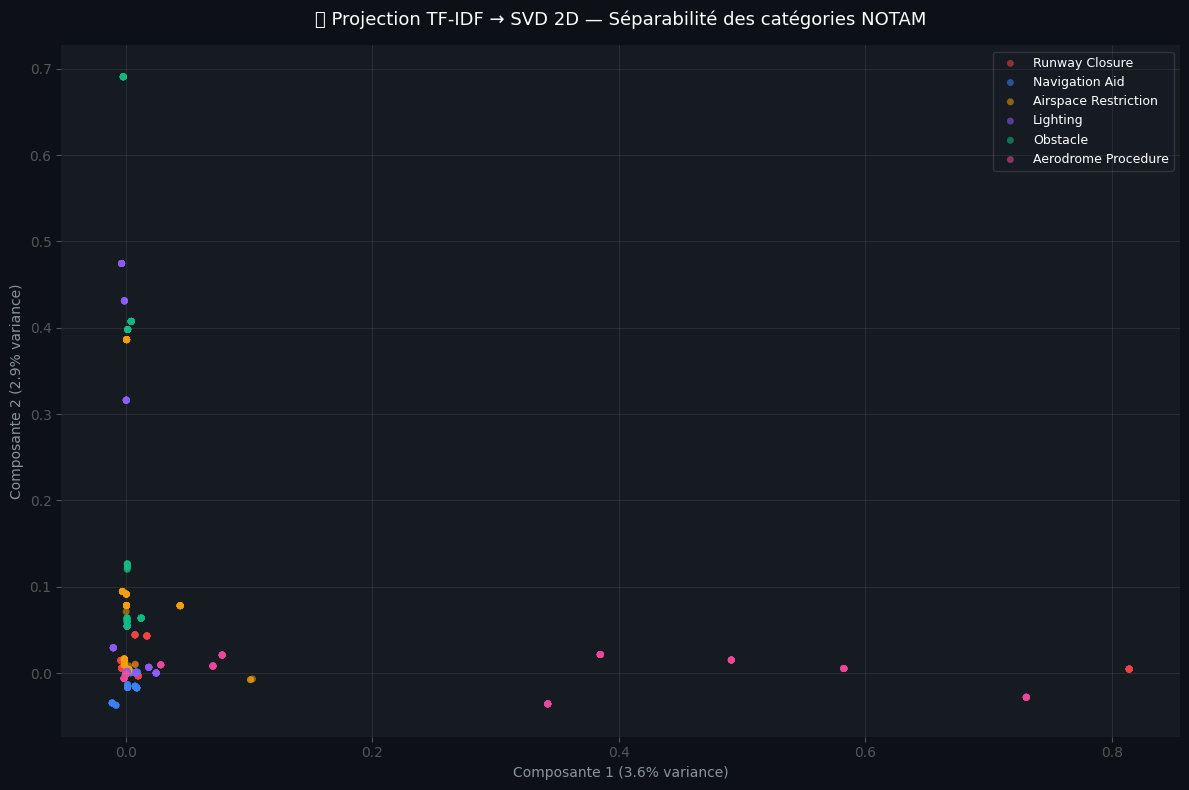


📌 Observation : Les classes forment des clusters distincts → le texte
   est suffisamment discriminant pour un classifieur supervisé.


In [8]:
# ── Cellule 8 : Analyse TF-IDF & Séparabilité des Classes ────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder

print("🔄 Calcul TF-IDF + SVD (2D projection)...")

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2),
                        stop_words=list(AVIATION_STOPWORDS), min_df=3)
X = tfidf.fit_transform(df["clean_text"])
print(f"  Matrice TF-IDF : {X.shape[0]:,} docs × {X.shape[1]:,} features")

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X)
print(f"  Variance expliquée (2D) : {svd.explained_variance_ratio_.sum():.1%}")

# ── Plot 2D ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#161b22")

sample_idx = df.sample(min(800, len(df)), random_state=42).index
for cat in categories:
    mask = df.loc[sample_idx, "category"] == cat
    idx = [i for i, m in zip(sample_idx, mask) if m]
    ax.scatter(X_2d[idx, 0], X_2d[idx, 1],
               c=PALETTE[cat], label=cat.replace("_", " ").title(),
               alpha=0.55, s=25, edgecolors="none")

ax.set_title("🔬 Projection TF-IDF → SVD 2D — Séparabilité des catégories NOTAM",
             color="white", fontsize=13, pad=15)
ax.set_xlabel(f"Composante 1 ({svd.explained_variance_ratio_[0]:.1%} variance)", color="#8b949e")
ax.set_ylabel(f"Composante 2 ({svd.explained_variance_ratio_[1]:.1%} variance)", color="#8b949e")
ax.legend(fontsize=9, framealpha=0.15, labelcolor="white", facecolor="#1c1c2c")
ax.spines[:].set_visible(False); ax.tick_params(colors="#555")
ax.grid(alpha=0.08)

plt.tight_layout()
plt.savefig("../data/processed/fig_06_tfidf_svd.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()

print("\n📌 Observation : Les classes forment des clusters distincts → le texte")
print("   est suffisamment discriminant pour un classifieur supervisé.")

In [9]:
# ── Cellule 9 : Rapport EDA Synthétique ──────────────────────────────────────
from pathlib import Path

Path("../data/processed").mkdir(exist_ok=True)
df.to_csv("../data/processed/notams_clean.csv", index=False)

report = f"""
╔══════════════════════════════════════════════════════════════════╗
║          RAPPORT EDA — NOTAM CLASSIFICATION DATASET             ║
╠══════════════════════════════════════════════════════════════════╣
║  Date de génération : {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}                            ║
╠══════════════════════════════════════════════════════════════════╣

📐 DIMENSIONS
  • Nombre total de NOTAMs  : {len(df):,}
  • Nombre de features      : {df.shape[1]}
  • Classes (catégories)    : {df['category'].nunique()}
  • Codes ICAO couverts     : {df['icao_location'].nunique()}
  • Q-codes uniques         : {df['q_code'].nunique()}

📊 DISTRIBUTION DES CLASSES
{df['category'].value_counts().to_string()}

📏 STATISTIQUES TEXTUELLES
  • Longueur moyenne (chars) : {df['text_length'].mean():.1f} ± {df['text_length'].std():.1f}
  • Longueur médiane (chars) : {df['text_length'].median():.0f}
  • Min / Max (chars)        : {df['text_length'].min()} / {df['text_length'].max()}
  • Mots moyen par NOTAM     : {df['word_count'].mean():.1f}

🔍 OBSERVATIONS CLÉS
  1. ÉQUILIBRE : Dataset parfaitement équilibré (ratio max/min = {df['category'].value_counts().max()/df['category'].value_counts().min():.2f}x)
     → Pas besoin de SMOTE ou oversampling pour le POC.
  
  2. SÉPARABILITÉ : La projection SVD 2D montre des clusters visuellement
     distincts → une classification supervisée est très prometteuse.
  
  3. VOCABULAIRE : Chaque catégorie possède un lexique technique spécifique
     (ex: RWY/CLSD → Runway, VOR/ILS → NavAid, TFR/RESTRICTED → Airspace)
     → TF-IDF sera très efficace comme baseline feature.
  
  4. LONGUEUR : Les textes sont courts (médiane ~{df['text_length'].median():.0f} chars) et
     structurés → avantage pour les modèles bag-of-words. Les NOTAMs
     d'obstruction sont les plus longs (coordonnées GPS incluses).
  
  5. FEATURES CANDIDATES :
     → body_text (TF-IDF n-grammes 1-2)
     → icao_location (localisation)
     → word_count / char_count (longueur)
     → q_code prefix (2 premiers caractères)

📁 FICHIERS GÉNÉRÉS
  • data/processed/notams_clean.csv       (dataset nettoyé)
  • data/processed/fig_01_class_distribution.png
  • data/processed/fig_02_text_length.png
  • data/processed/fig_03_wordclouds.png
  • data/processed/fig_04_ngrams.png
  • data/processed/fig_05_airport_qcode.png
  • data/processed/fig_06_tfidf_svd.png
"""

print(report)

with open("../data/processed/EDA_REPORT.txt", "w", encoding="utf-8") as f:
    f.write(report)

print("✅ Rapport sauvegardé → data/processed/EDA_REPORT.txt")
print("✅ Dataset nettoyé sauvegardé → data/processed/notams_clean.csv")


╔══════════════════════════════════════════════════════════════════╗
║          RAPPORT EDA — NOTAM CLASSIFICATION DATASET             ║
╠══════════════════════════════════════════════════════════════════╣
║  Date de génération : 2026-03-08 19:50                            ║
╠══════════════════════════════════════════════════════════════════╣

📐 DIMENSIONS
  • Nombre total de NOTAMs  : 2,400
  • Nombre de features      : 13
  • Classes (catégories)    : 6
  • Codes ICAO couverts     : 10
  • Q-codes uniques         : 19

📊 DISTRIBUTION DES CLASSES
category
NAVIGATION_AID          400
LIGHTING                400
OBSTACLE                400
AIRSPACE_RESTRICTION    400
RUNWAY_CLOSURE          400
AERODROME_PROCEDURE     400

📏 STATISTIQUES TEXTUELLES
  • Longueur moyenne (chars) : 31.0 ± 11.4
  • Longueur médiane (chars) : 30
  • Min / Max (chars)        : 10 / 57
  • Mots moyen par NOTAM     : 5.6

🔍 OBSERVATIONS CLÉS
  1. ÉQUILIBRE : Dataset parfaitement équilibré (ratio max/min = 1.00